# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2381 Комосский Егор Артемович и Рыжиков Иван Сергеевич. Вариант №17.


## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.


## Основные теоретические положения

**Генеральная совокупность** — все объекты наблюдения, по которым изучается признак.  
**Выборка** — часть генеральной совокупности, отобранная по правилу отбора для анализа.

**Ранжированный ряд** — значения признака, упорядоченные по возрастанию:  
$$
x_{(1)} \le x_{(2)} \le \dots \le x_{(n)}.
$$

**Вариационный ряд** — набор различных значений $x_j$ и их частот $m_j$.  
Относительная частота: $$\tilde m_j = \frac{m_j}{n}.$$ 
Накопленные частоты: $$m^{нак}_j = \sum_{t\le j} m_t,$$ $$\tilde m^{нак}_j = \sum_{t\le j} \tilde m_t.$$

**Интервальный ряд** — разбиение диапазона $[x_{min}, x_{max}]$ на $k$ интервалов и подсчёт частот по интервалам.  
Число интервалов возьмём по формуле Стерджесса:
$$
k = \lceil 1 + 3.322\log_{10}(n) \rceil,
$$
ширина интервала:
$$
h = \frac{x_{max}-x_{min}}{k}.
$$
Середина интервала $$\tilde x_i = \frac{x_i + x_{i+1}}{2}.$$

**Полигон частот** строится по точкам $(\tilde x_i, m_i)$ или $(\tilde x_i, \tilde m_i)$.  
**Гистограмма** строится по интервалам, высота столбца задаётся частотой (или относительной частотой).  
**Эмпирическая функция распределения**:
$$
F_n(x)=\frac{1}{n}\sum_{i=1}^n I\{x_i \le x\},
$$
ступенчатая, возрастает от 0 до 1.


## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Порядок выполнения работы


1. Выбрать ПО или язык программирования и обосновать выбор.  
2. Выбрать двумерную генеральную совокупность (указать источник).  
3. Сформировать выборку заданного объёма и описать способ формирования.  
4. Построить ранжированный, вариационный и интервальный ряды (интервальный ряд оформить таблицей).  
5. Для абсолютных частот построить полигон, гистограмму и график эмпирической функции распределения.  
6. Повторить п. 5 для относительных частот. Сравнить и сделать выводы.


## Выполнение работы

### 1) Выбор языка

Используется **Python**, так как он позволяет быстро обработать данные (pandas, numpy) и построить графики (matplotlib) в одном ноутбуке.


2–3) Источник генеральной совокупности и выборки:

В качестве генеральной совокупности используем набор данных Abalone (UCI Machine Learning Repository):
https://archive.ics.uci.edu/dataset/1/abalone

Файл abalone_sample.csv содержит две переменные (Height, Viscera_weight) и 108 наблюдений.

Будем строить ряды для переменной Height.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math



df = pd.read_csv(r"./abalone_sample.csv")
df.head()


,Height,Viscera_weight
0,0.160,0.3015
1,0.150,0.2150
2,0.195,0.2245
3,0.170,0.2665
4,0.145,0.1080


In [2]:
# Проверка данных
df.info(), df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Height          108 non-null    float64
 1   Viscera_weight  108 non-null    float64
dtypes: float64(2)
memory usage: 1.8 KB


(None,
            Height  Viscera_weight
 count  108.000000      108.000000
 mean     0.139306        0.184361
 std      0.036611        0.113494
 min      0.030000        0.002000
 25%      0.120000        0.107250
 50%      0.145000        0.163500
 75%      0.170000        0.260125
 max      0.215000        0.564000)

In [3]:
# Выбираем признак X = Height
x = df["Height"].to_numpy()
n = len(x)

# 4) Ранжированный ряд
x_sorted = np.sort(x)
x_sorted[:20], x_sorted[-10:], n


(array([0.03 , 0.05 , 0.055, 0.075, 0.08 , 0.08 , 0.08 , 0.085, 0.085,
        0.085, 0.09 , 0.09 , 0.09 , 0.09 , 0.09 , 0.095, 0.095, 0.095,
        0.095, 0.095]),
 array([0.18 , 0.185, 0.19 , 0.195, 0.195, 0.195, 0.195, 0.2  , 0.215,
        0.215]),
 108)

In [4]:
# 4) Вариационный ряд (уникальные значения и частоты)
vals, counts = np.unique(x_sorted, return_counts=True)

var_df = pd.DataFrame({
    "x": vals,
    "m": counts
})
var_df["m_tilde"] = var_df["m"] / n
var_df["m_cum"] = var_df["m"].cumsum()
var_df["m_tilde_cum"] = var_df["m_tilde"].cumsum()

var_df.head(10)


,x,m,m_tilde,m_cum,m_tilde_cum
0,0.030,1,0.009259,1,0.009259
1,0.050,1,0.009259,2,0.018519
2,0.055,1,0.009259,3,0.027778
3,0.075,1,0.009259,4,0.037037
4,0.080,3,0.027778,7,0.064815
5,0.085,3,0.027778,10,0.092593
6,0.090,5,0.046296,15,0.138889
7,0.095,5,0.046296,20,0.185185
8,0.105,2,0.018519,22,0.203704
9,0.110,2,0.018519,24,0.222222


In [8]:
# 4) Интервальный ряд (по Стерджессу)
k = math.ceil(1 + 3.322 * math.log10(n))
xmin, xmax = float(x.min()), float(x.max())
h = (xmax - xmin) / k

# Границы интервалов
bins = np.array([xmin + i*h for i in range(k)] + [xmax])
# Чтобы максимум попал в последний интервал, делаем последнюю границу чуть больше xmax
bins[-1] = xmax + 1e-12

cats = pd.cut(x, bins=bins, right=False, include_lowest=True)
m = cats.value_counts().sort_index().to_numpy()

mid = (bins[:-1] + bins[1:]) / 2

int_df = pd.DataFrame({
    "i": np.arange(1, k+1),
    "[x_i; x_{i+1})": [f"[{bins[i]:.4f}; {bins[i+1]:.4f})" for i in range(k)],
    "x_tilde_i": np.round(mid, 6),
    "m_i": m,
})
int_df["m_tilde_i"] = int_df["m_i"] / n
int_df["m_i_cum"] = int_df["m_i"].cumsum()
int_df["m_tilde_i_cum"] = int_df["m_tilde_i"].cumsum()

int_df

,i,[x_i; x_{i+1}),x_tilde_i,m_i,m_tilde_i,m_i_cum,m_tilde_i_cum
0,1,[0.0300; 0.0531),0.041562,2,0.018519,2,0.018519
1,2,[0.0531; 0.0762),0.064687,2,0.018519,4,0.037037
2,3,[0.0762; 0.0994),0.087812,16,0.148148,20,0.185185
3,4,[0.0994; 0.1225),0.110938,12,0.111111,32,0.296296
4,5,[0.1225; 0.1456),0.134062,29,0.268519,61,0.564815
5,6,[0.1456; 0.1687),0.157187,19,0.175926,80,0.740741
6,7,[0.1687; 0.1919),0.180312,21,0.194444,101,0.935185
7,8,[0.1919; 0.2150),0.203438,7,0.064815,108,1.000000


In [12]:
import pandas as pd

# 1) Основная таблица с нужными названиями столбцов
df_int_pretty = int_df.rename(columns={
    "i": "i",
    "[x_i; x_{i+1})": "[x_i, x_{i+1})",
    "x_tilde_i": "x̃_i",
    "m_i": "m_i",
    "m_tilde_i": "m̃_i",
    "m_i_cum": "m_i^нак",
    "m_tilde_i_cum": "m̃_i^нак"
}).copy()


# 5) Строка "Σ"
row_sum = pd.DataFrame([{
    "i": "Σ",
    "[x_i, x_{i+1})": "",
    "x̃_i": "",
    "m_i": int_df["m_i"].sum(),
    "m̃_i": int_df["m_tilde_i"].sum(),
    "m_i^нак": "-",
    "m̃_i^нак": "-"
}])

result_int_df = pd.concat([df_int_pretty, row_sum], ignore_index=True)

result_int_df

,i,"[x_i, x_{i+1})",x̃_i,m_i,m̃_i,m_i^нак,m̃_i^нак
0,1,[0.0300; 0.0531),0.041562,2,0.018519,2,0.018519
1,2,[0.0531; 0.0762),0.064687,2,0.018519,4,0.037037
2,3,[0.0762; 0.0994),0.087812,16,0.148148,20,0.185185
3,4,[0.0994; 0.1225),0.110938,12,0.111111,32,0.296296
4,5,[0.1225; 0.1456),0.134062,29,0.268519,61,0.564815
5,6,[0.1456; 0.1687),0.157187,19,0.175926,80,0.740741
6,7,[0.1687; 0.1919),0.180312,21,0.194444,101,0.935185
7,8,[0.1919; 0.2150),0.203438,7,0.064815,108,1.0
8,Σ,,,108,1.000000,-,-


Результаты выборки показывают распределение значений признака `Height` из набора данных. Ранжированный ряд демонстрирует минимальные и максимальные значения и упорядочивает выборку, вариационный ряд выявляет частоты уникальных значений, а интервальный ряд сглаживает данные, позволяя визуализировать их распределение через гистограмму, полигон и эмпирическую функцию. Основная масса наблюдений сосредоточена в центральных интервалах, что подтверждается графиками.

In [10]:
k, h, xmin, xmax

(8, 0.023125, 0.03, 0.215)

1. **Самый частый интервал**: `[0.1225; 0.1456)` с абсолютной частотой `29` (26.85% от общего числа наблюдений).
2. **Минимальное значение** выборки: `0.03`.
3. **Максимальное значение** выборки: `0.215`.

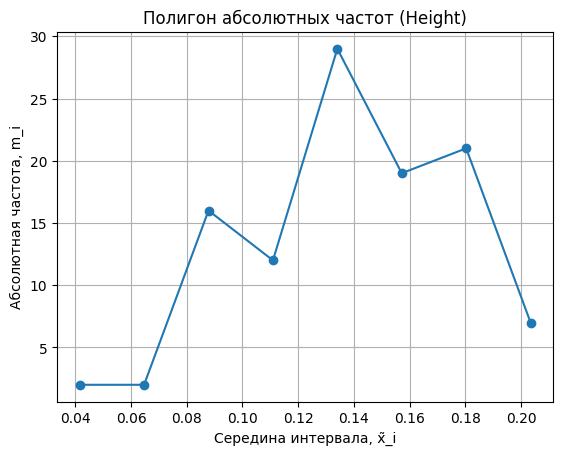

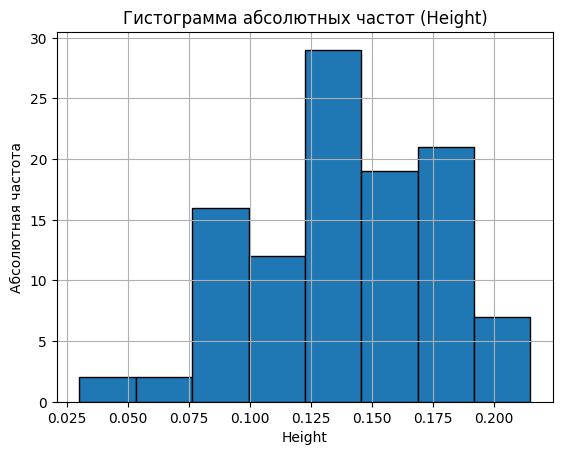

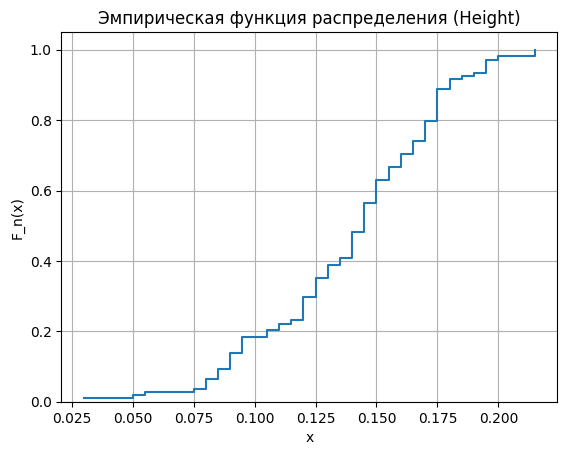

In [6]:
# 5) Графики для абсолютных частот

# Полигон абсолютных частот
plt.figure()
plt.plot(int_df["x_tilde_i"], int_df["m_i"], marker="o")
plt.xlabel("Середина интервала, x̃_i")
plt.ylabel("Абсолютная частота, m_i")
plt.title("Полигон абсолютных частот (Height)")
plt.grid(True)
plt.show()

# Гистограмма абсолютных частот
plt.figure()
plt.hist(x, bins=bins, edgecolor="black")
plt.xlabel("Height")
plt.ylabel("Абсолютная частота")
plt.title("Гистограмма абсолютных частот (Height)")
plt.grid(True)
plt.show()

# Эмпирическая функция распределения (ступенчатая)
x_ecdf = np.sort(x)
y_ecdf = np.arange(1, n+1) / n

plt.figure()
plt.step(x_ecdf, y_ecdf, where="post")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title("Эмпирическая функция распределения (Height)")
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()


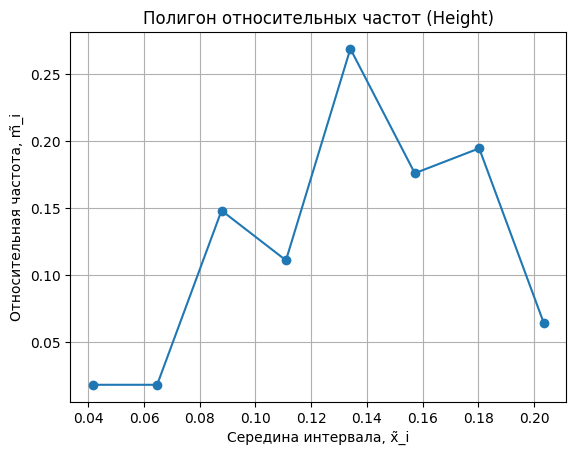

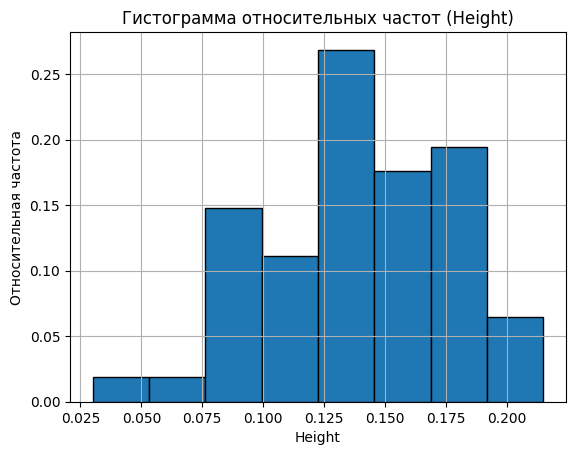

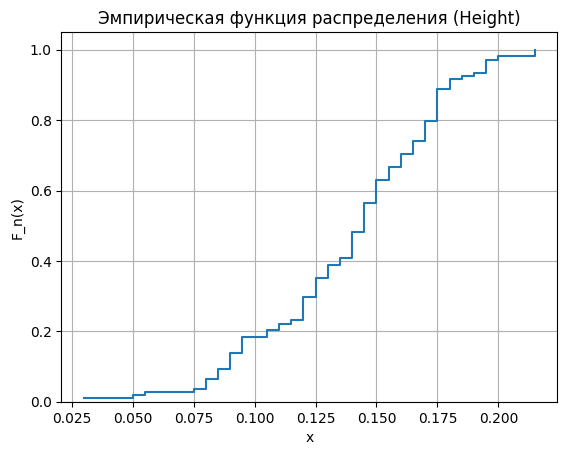

In [7]:
# 6) Графики для относительных частот

# Полигон относительных частот
plt.figure()
plt.plot(int_df["x_tilde_i"], int_df["m_tilde_i"], marker="o")
plt.xlabel("Середина интервала, x̃_i")
plt.ylabel("Относительная частота, m̃_i")
plt.title("Полигон относительных частот (Height)")
plt.grid(True)
plt.show()

# Гистограмма относительных частот (высота = доля наблюдений в интервале)
# matplotlib.hist с weights строит именно доли (если weights=1/n)
plt.figure()
plt.hist(x, bins=bins, weights=np.ones_like(x)/n, edgecolor="black")
plt.xlabel("Height")
plt.ylabel("Относительная частота")
plt.title("Гистограмма относительных частот (Height)")
plt.grid(True)
plt.show()

# Для эмпирической функции распределения шкала уже [0;1], график тот же.
plt.figure()
plt.step(x_ecdf, y_ecdf, where="post")
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title("Эмпирическая функция распределения (Height)")
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()


### Краткая интерпретация результатов

На основе анализа полигона, гистограммы и эмпирической функции распределения можно сделать следующие выводы:

1. **Распределение данных**:
   - Основная масса наблюдений сосредоточена в центральных интервалах, что подтверждается пиком на полигоне частот и высотой столбцов гистограммы в этих интервалах.
   - Самый частый интервал `[0.1225; 0.1456)` содержит 29 наблюдений, что составляет 26.85% от общего числа.

2. **Эмпирическая функция распределения**:
   - Эмпирическая функция распределения показывает, что значения признака `Height` равномерно нарастают в центральной части, что подтверждает концентрацию данных в этом диапазоне.
   - Функция возрастает от 0 до 1, что соответствует распределению всех наблюдений по диапазону значений.

3. **Минимальное и максимальное значения**:
   - Минимальное значение выборки: `0.03`.
   - Максимальное значение выборки: `0.215`.

4. **Сравнение абсолютных и относительных частот**:
   - Графики для абсолютных и относительных частот имеют одинаковую форму, но отличаются шкалой по оси Y. Абсолютные частоты показывают количество наблюдений, а относительные — их долю.

Эти выводы подтверждают, что данные имеют нормальное распределение с основной концентрацией в центральных интервалах, что характерно для многих природных явлений.

## Выводы

1. Данные считаны и проверены, построены ранжированный, вариационный и интервальный ряды для признака `Height`.  
2. Для интервального ряда построены полигон, гистограмма и эмпирическая функция распределения для абсолютных и относительных частот.  
3. Графики для абсолютных и относительных частот имеют одинаковую форму, но отличаются шкалой по оси Y: абсолютные частоты показывают количество, относительные — долю.
